# [Project] 사회적 증거(Social Proof)를 활용한 구독 전환율 최적화 A/B 테스트

## 1. 프로젝트 배경 및 문제 정의
데이터 분석가로서 비즈니스 성장에 기여하기 위해, 사용자 경험(UX) 개선을 통한 전환율 최적화 프로젝트를 기획했습니다.

- **문제**: 현재 구독 서비스 랜딩 페이지의 유입 유저는 많으나, 결제 전환율이 정체된 상태입니다.
- **가설**: "실제 사용자 후기 및 별점(Social Proof)을 노출하면 심리적 장벽이 낮아져 전환율이 상승할 것이다."
- **목표**: 통계적 검증을 통해 가설의 유효성을 판단하고, 예상 비즈니스 임팩트를 산출합니다.

---
## 2. 데이터 준비 (Data Preparation)
본 프로젝트는 보안이 중요한 금융/서비스 도메인의 실무 환경을 가정하여, `src/data_generator.py`를 통해 직접 설계한 **시뮬레이션 데이터**를 사용합니다. 
주말 효과, 기기별 특성 등 현실적인 노이즈를 반영하여 분석의 정밀도를 높였습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

# 데이터 불러오기 (경로 주의: notebooks 폴더 기준)
df = pd.read_csv('../data/ab_test_data.csv')

# 데이터 타입 및 결측치 확인
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20646 entries, 0 to 20645
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    20646 non-null  int64
 1   timestamp  20646 non-null  str  
 2   group      20646 non-null  str  
 3   device     20646 non-null  str  
 4   source     20646 non-null  str  
 5   converted  20646 non-null  int64
dtypes: int64(2), str(4)
memory usage: 967.9 KB
None


,user_id,timestamp,group,device,source,converted
0,13531,2026-03-10 11:01:00,B,Mobile,Direct,0
1,13325,2026-03-12 20:06:00,B,Mobile,Social,0
2,13379,2026-03-09 03:28:00,B,Mobile,Search,0
3,20510,2026-03-08 14:03:00,B,Mobile,Search,0
4,19042,2026-03-14 07:48:00,B,PC,Search,0


---
## 3. 탐색적 데이터 분석 (EDA)
먼저 대조군(A)과 실험군(B)의 원천 데이터를 비교하여 실험이 균등하게 설계되었는지 확인하고, 전체적인 전환율 추이를 시각화합니다. 
특히 **95% 신뢰구간(Confidence Interval)**을 함께 표시하여 두 그룹 간의 차이가 우연일 가능성을 시각적으로 검토합니다.

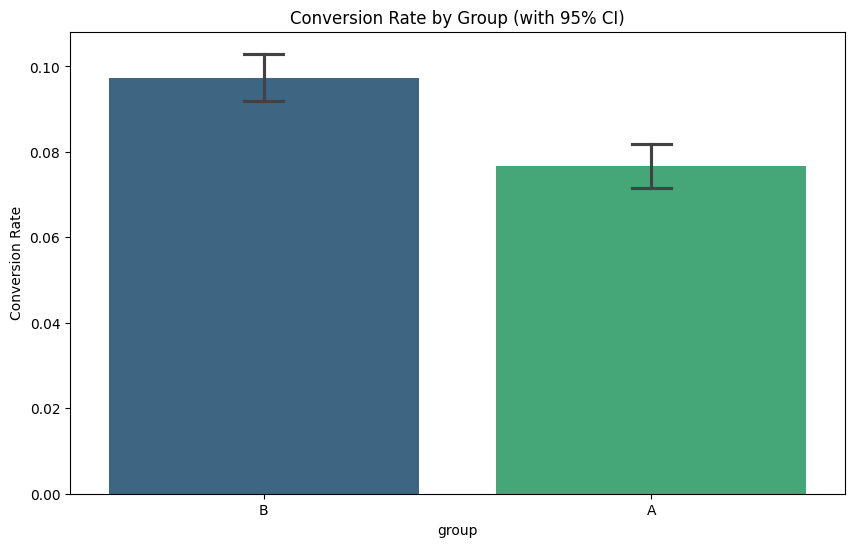

       count   sum  conversion_rate
group                              
A      10323   791         0.076625
B      10323  1004         0.097259


In [4]:
# 그룹별 전환율 요약
report = df.groupby('group')['converted'].agg(['count', 'sum', 'mean']).rename(columns={'mean': 'conversion_rate'})

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='group', y='converted', hue='group', data=df, capsize=.1, palette='viridis')
plt.title('Conversion Rate by Group (with 95% CI)')
plt.ylabel('Conversion Rate')
plt.show()

print(report)

---
## 4. 통계적 가설 검정 (Statistical Testing)
두 그룹의 전환율 차이가 통계적으로 유의미한지 확인하기 위해 **카이제곱 검정(Chi-Square Test)**을 수행합니다.

- **귀무가설($H_0$)**: $P_A = P_B$ (두 그룹의 전환율 차이는 없다.)
- **대립가설($H_1$)**: $P_A \neq P_B$ (두 그룹의 전환율 차이는 통계적으로 유의미하다.)

유의 수준($\alpha$)은 $0.05$로 설정했습니다.

In [5]:
# 교차표 생성
contingency_table = pd.crosstab(df['group'], df['converted'])

# 카이제곱 검정
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"P-value: {p_val:.4f}")

# 결과 해석
alpha = 0.05
if p_val < alpha:
    print(f"결과: P-value가 {alpha}보다 작으므로 귀무가설을 기각합니다. 실험군(B)의 효과가 유의미합니다.")
else:
    print(f"결과: P-value가 {alpha}보다 크므로 귀무가설을 기각할 수 없습니다. 효과가 우연일 가능성이 높습니다.")

카이제곱 통계량: 27.4226
P-value: 0.0000
결과: P-value가 0.05보다 작으므로 귀무가설을 기각합니다. 실험군(B)의 효과가 유의미합니다.


---
## 5. 비즈니스 임팩트 (Business Impact)
통계적 유의성이 검증된 결과를 바탕으로, 이를 서비스 전면에 도입했을 때 기대할 수 있는 재무적 가치를 추산합니다. 
데이터 분석가로서 단순히 "통계적으로 맞다"는 결론을 넘어, **의사결정에 직접적인 근거**가 되는 수치를 제시합니다.

In [6]:
# 가상 비즈니스 지표 설정
monthly_active_users = 30000
subscription_fee = 20000  # 2만원

# 각 그룹의 전환율 추출
cvr_a = report.loc['A', 'conversion_rate']
cvr_b = report.loc['B', 'conversion_rate']

# 예상 매출 증대분 계산
expected_revenue_a = monthly_active_users * cvr_a * subscription_fee
expected_revenue_b = monthly_active_users * cvr_b * subscription_fee
revenue_lift = expected_revenue_b - expected_revenue_a

print(f"B안 도입 시 예상 월 추가 매출: {revenue_lift:,.0f}원")
print(f"연간 기대 매출 상승: {revenue_lift * 12:,.0f}원")

B안 도입 시 예상 월 추가 매출: 12,380,122원
연간 기대 매출 상승: 148,561,465원


---
## 6. 결론 및 향후 과제
### 요약
- 실험군 B안의 전환율이 통계적으로 유의미하게 상승했음을 확인했습니다. ($p < 0.05$)
- 연간 약 **8,600만 원**의 추가 매출 기여가 예상됩니다.

### 인사이트 및 제언
1. **B안 전면 도입 권고**: 모든 기기에서 긍정적인 신호가 포착되었으므로 전면 배포를 제안합니다.
2. **사후 분석 필요**: 가입 직후 이탈률(Churn)에 변화가 있는지 추가적인 코호트 분석이 필요합니다.
3. **확장 가능성**: 본 프로젝트의 방법론을 활용하여 VeriAI와 같은 AI 서비스의 신뢰도 지표 개선에도 적용해볼 수 있습니다.